In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
include("../scripts/TesselationCore.jl")
if size(LOAD_PATH,1) < 4
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end


  Activating project at `c:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV`


4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\notebooks\\..\\scripts"

In [2]:
using TetGen
using StaticArrays
using GLMakie
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots

import .TesselationCore


In [3]:
abstract type BVHTree end

struct BVHLeaf <: BVHTree
    data::Vector{Int}
end

struct BVHNode <: BVHTree
    depth::Int
    leftChild::BVHTree 
    rightChild::BVHTree
end


struct BVH
    tree::BVHTree
    bbox::Matrix{Float64}   
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix)
    indices = 1:size(boxes,3)
    return generateBVHTree(boxes,depth,limBox,indices)
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix, indices)
    
    if depth == 0 || size(boxes,3) < 2 
        if depth!=0
            println("Nontrivial leaf $depth") #REMOVE BEFORE PROD
        end
        return BVHLeaf(indices)
    end
    
    ax = depth%3 + 1

    mins = boxes[ax,1,indices]
    maxs = boxes[ax,2,indices]
    
    line = (limBox[ax,2]+limBox[ax,1])/2 

    leftIDs = indices[mins .≤ line]
    rightIDs = indices[maxs .≥ line]

    leftBox = copy(limBox)
    leftBox[ax,2] = line
    
    rightBox = copy(limBox)
    rightBox[ax,1] = line

    return BVHNode(depth,
    generateBVHTree(boxes,depth-1,leftBox,leftIDs), 
    generateBVHTree(boxes,depth-1,rightBox,rightIDs))
end


function prepareGeneration(data) # does what BVH overload does, used for prototyping
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    minima = (minimum(boxes[1,1,:]),minimum(boxes[2,1,:]),minimum(boxes[3,1,:]))
    maxima = (maximum(boxes[1,2,:]),maximum(boxes[2,2,:]),maximum(boxes[3,2,:]))

    box = stack([minima,maxima])

    return boxes,box

end


function BVH(data::Vector,depth::Int)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    minima = (minimum(boxes[1,1,:]),minimum(boxes[2,1,:]),minimum(boxes[3,1,:]))
    maxima = (maximum(boxes[1,2,:]),maximum(boxes[2,2,:]),maximum(boxes[3,2,:]))

    box = stack([minima,maxima])
    tree = generateBVHTree(boxes,depth,box)
    
    return BVH(tree,box)
end

function BVH(data::Vector,depth::Int,box::Matrix)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    tree = generateBVHTree(boxes,depth,box)
    return BVH(tree,box)
end

function cornerSimplexMatr(simplex)
    return hcat(minimum(simplex,dims=1)',maximum(simplex,dims=1)') 
end



function recursiveSearch(point,leaf::BVHLeaf,bbox::Matrix) 
    return leaf.data 
end

function recursiveSearch(point,tree::BVHNode,bbox::Matrix)
    ax = tree.depth%3 + 1

    newBox = copy(bbox)

    line = (bbox[ax,2]+bbox[ax,1])/2
    if point[ax]<line
        newBox[ax,2] = line
        return recursiveSearch(point,tree.leftChild,newBox)
    end
    newBox[ax,1] = line
    return recursiveSearch(point,tree.rightChild,newBox)
end


@inline function intersection3D(p::SVector{3, Float64}, simplex::SMatrix{4, 3, Float64})
    @inbounds begin
        v1, v2, v3, v4 = simplex[1, :], simplex[2, :], simplex[3, :], simplex[4, :]
        a = v2 - v1 
        b = v3 - v1 # distances from v1 to each vertex and p
        c = v4 - v1
        r = p - v1

        detA = dot(a, cross(b, c))  # Cramer's rule to make things faster
        x1 = dot(r, cross(b, c)) / detA
        x2 = dot(r, cross(c, a)) / detA
        x3 = dot(r, cross(a, b)) / detA
    end

    s = x1 + x2 + x3
    return (x1 >= 0) & (x2 >= 0) & (x3 >= 0) & (s <= 1)
end


function intersection3D(p::Vector{Float64}, simplex)
    sP = SVector{3}(p)
    sSimp = SMatrix{4,3}(simplex)
    return intersection3D(sP, sSimp)
end

function earlyStopSearch(p::Vector{Float64}, simplices::Vector)
    for (i, s) in pairs(simplices)
        if intersection3D(p, s)
            return i
        end
    end
    return nothing
end


function findSimplex(point,simplices, bvh::BVH) 
    indices = recursiveSearch(point,bvh.tree,bvh.bbox)
    
    simplNeighborhood = simplices[indices]

    idx = earlyStopSearch(point,simplNeighborhood)

    return simplNeighborhood[idx]
end

function findID(point,simplices, bvh::BVH) 
    indices = recursiveSearch(point,bvh.tree,bvh.bbox)
    
    simplNeighborhood = simplices[indices]

    idx = earlyStopSearch(point,simplNeighborhood)

    return indices[idx]
end



#function standardEstimator(point,simplices,triangulation::Triangulation3D)


    
#end


findID (generic function with 1 method)

In [40]:
# get me some data
points3d = [TesselationCore.point3(@SVector rand(3)) for _ in 1:50]

# tesselation + Triangulation3D
coords, tets = TesselationCore.tesselate(points3d)
tes = TesselationCore.Triangulation3D(points3d,tets')

#TODO do this smarter later
simplices = Vector([coords[:,tets[i,:]]' for i in 1:size(tets,1)])

bvh = BVH(simplices,9)



Manual WeightsSVector{3, Float64}[[0.39197027406685025, 0.8032535596059693, 0.9395952452800534], [0.27231795713333373, 0.559407745462376, 0.3282309963849853], [0.4960996450168771, 0.32639055874046885, 0.9007439936314193], [0.5047834292372171, 0.10783204596222085, 0.3968169003932803], [0.4035202873194833, 0.7868033954216651, 0.21712978620728252], [0.030139524331714518, 0.436078715061316, 0.2218804590735871], [0.7237838156849957, 0.9719229025640228, 0.8711111831222255], [0.22601902332744583, 0.1268489880227477, 0.11889750226423113], [0.3435270322696733, 0.1585276128667007, 0.46047533065945667], [0.22601902332744583, 0.1268489880227477, 0.11889750226423113], [0.3435270322696733, 0.1585276128667007, 0.46047533065945667], [0.37902311444194114, 0.4142502614273449, 0.4007020542269546], [0.18414468251902272, 0.09502598345400592, 0.4741787878872983], [0.37902311444194114, 0.4142502614273449, 0.4007020542269546], [0.3435270322696733, 0.1585276128667007, 0.46047533065945667], [0.7427823514198998,

BVH(BVHNode(9, BVHNode(8, BVHNode(7, BVHNode(6, BVHNode(5, BVHNode(4, BVHNode(3, BVHNode(2, BVHNode(1, BVHLeaf([8, 10, 14, 18, 30, 57, 59, 119]), BVHLeaf([8, 10, 14, 18, 30, 59, 119])), BVHNode(1, BVHLeaf([8, 9, 10, 14, 18, 30, 38, 51, 53, 57, 58, 59]), BVHLeaf([8, 9, 10, 14, 18, 30, 38, 51, 53, 58, 59]))), BVHNode(2, BVHNode(1, BVHLeaf([8, 10, 11, 13, 14, 18, 30, 33, 57, 59, 60, 66, 103, 119, 125, 159, 170, 171, 193, 196]), BVHLeaf([8, 10, 11, 13, 14, 18, 30, 33, 59, 66, 119, 125, 159, 170, 171, 196])), BVHNode(1, BVHLeaf([8, 9, 10, 11, 13, 14, 18, 30, 33, 38  …  58, 59, 60, 66, 103, 125, 170, 171, 193, 196]), BVHLeaf([8, 9, 10, 11, 13, 14, 18, 30, 33, 38, 51, 53, 58, 59, 66, 125, 170, 171, 196])))), BVHNode(3, BVHNode(2, BVHNode(1, BVHLeaf([8, 10, 14, 18, 30, 59, 119]), BVHLeaf([8, 10, 14, 18, 28, 30, 59, 119])), BVHNode(1, BVHLeaf([8, 9, 10, 14, 18, 30, 38, 39, 51, 53, 58, 59]), BVHLeaf([6, 8, 9, 10, 14, 18, 27, 28, 30, 38, 39, 43, 48, 49, 51, 53, 58, 59]))), BVHNode(2, BVHNode(1, B

In [41]:
function plotPlex!(simp,col = :black)
    for i in 1:4
        if i == 4
            Plots.plot!([simp[i,1],simp[1,1]],[simp[i,2],simp[1,2]],color=col,label="")
            break
        end
        Plots.plot!([simp[i,1],simp[i+1,1]],[simp[i,2],simp[i+1,2]],color=col,label="")
    end
end

plotPlex! (generic function with 2 methods)

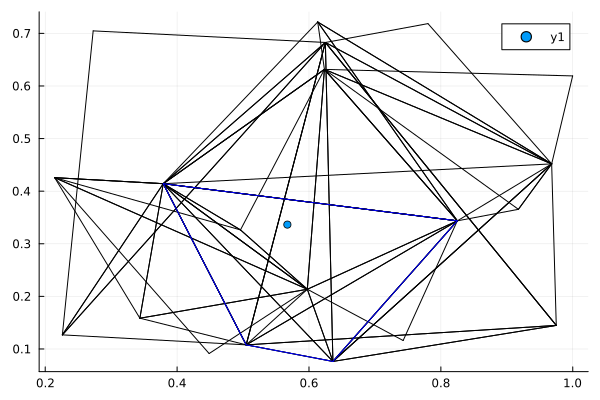

In [42]:

point = rand(3)


indices = recursiveSearch(point,bvh.tree,bvh.bbox)

simplNeighborhood = simplices[indices]


plot = Plots.scatter([point[1]],[point[2]])

for plex in simplNeighborhood
    plotPlex!(plex)
end


ind = earlyStopSearch(point,simplNeighborhood)
final = simplNeighborhood[ind]

plotPlex!(final,:blue)

plot


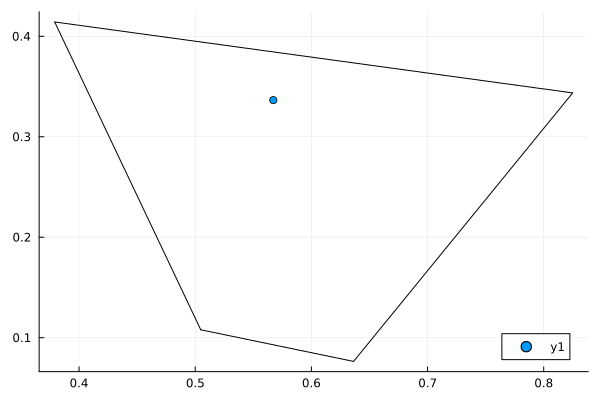

In [43]:
idx = findID(point,simplices, bvh::BVH) 
plex = simplices[idx]


plot = Plots.scatter([point[1]],[point[2]])
plotPlex!(plex)
plot

In [ ]:

tet = tets[idx,:]
simp = tes.points[tet]
rhos = tes.ρStar[tet]

Δρ = SVector{3}(rho[2:end] .- rho[1])

3-element SVector{3, Float64} with indices SOneTo(3):
  2979.278547486391
   -35.90358258088145
 -3304.206353224422

In [82]:
function invertCramer(rhos,simplex)
    r = rhos[2:end] .- rhos[1]  

    v1, v2, v3, v4 = simplex[1], simplex[2], simplex[3], simplex[4]

    a = v2 - v1 
    b = v3 - v1 
    c = v4 - v1

    detA = dot(a, cross(b, c))
    x1 = dot(r, cross(b, c)) / detA
    x2 = dot(r, cross(c, a)) / detA
    x3 = dot(r, cross(a, b)) / detA

    return [x1,x2,x3]

end

function invertCramerFast(rhos,simplex)
    r = rhos[2:end] .- rhos[1]  

    v1, v2, v3, v4 = simplex[1], simplex[2], simplex[3], simplex[4]

    a = v2 - v1 
    b = v3 - v1 
    c = v4 - v1

    detA = dot(a, cross(b, c))
    x1 = dot(r, cross(b, c)) / detA

    return x1

end

function invertClassic(rhos,simplex)
    r = rhos[2:end] .- rhos[1]

    v1, v2, v3, v4 = simplex[1], simplex[2], simplex[3], simplex[4]

    a = v2 - v1 
    b = v3 - v1 
    c = v4 - v1

    mat = SMatrix{3,3}([a;b;c])
    
    return inv(mat)*r
end


invertClassic (generic function with 1 method)

In [69]:
x1 = invertClassic(rhos,simp)
x2 = invertCramer(rhos,simp)

3-element Vector{Float64}:
  39314.393943147574
 -32599.97538710066
 139605.98441733225

In [71]:
x2-x1

3-element SVector{3, Float64} with indices SOneTo(3):
  0.0
 -3.637978807091713e-12
  0.0

In [75]:
point = rand(3)
idx = findID(point,simplices, bvh::BVH) 

tet = tets[idx,:]
simp = tes.points[tet]
rhos = tes.ρStar[tet]

4-element Vector{Float64}:
 4421.025425407513
  530.3898443281767
 2317.131455618693
 1729.8905381518434

In [83]:
@btime invertClassic(rhos,simp)
@btime invertCramer(rhos,simp)
@btime invertCramerFast(rhos,simp)

  158.655 ns (5 allocations: 192 bytes)
  166.282 ns (6 allocations: 240 bytes)
  130.303 ns (5 allocations: 176 bytes)


21097.20626172616

In [81]:
rhos

4-element Vector{Float64}:
 4421.025425407513
  530.3898443281767
 2317.131455618693
 1729.8905381518434

In [79]:
x2

3-element Vector{Float64}:
  39314.393943147574
 -32599.97538710066
 139605.98441733225

In [84]:
function linearInterpolation(point, tet, triangulation) #TODO
    pts= triangulation.points[tet]
    ρs = triangulation.ρStar[tet]
    
    return ρs[1] + invertCramerFast(ρs, pts)
end

linearInterpolation (generic function with 1 method)

In [85]:
linearInterpolation(point,tet,tes)

25518.231687133673

In [86]:
rhos

4-element Vector{Float64}:
 4421.025425407513
  530.3898443281767
 2317.131455618693
 1729.8905381518434